In [1]:
from common_config import *

In [2]:
import pandas as pd
classes = pd.read_pickle(CLASSES)
N_LAYERS = 42

In [3]:
classes.keys()

dict_keys(['sarcastic_surfpos', 'paired_sincere_pos', 'sarcastic_surfneg', 'paired_sincere_neg', 'baseline_sincere_pos', 'baseline_sincere_neg'])

In [4]:
from huggingface_hub import login
import os
from dotenv import load_dotenv

load_dotenv()

if "HF_TOKEN" in os.environ:
    print("Success: HF_TOKEN loaded.")

login(token=os.environ["HF_TOKEN"])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Success: HF_TOKEN loaded.


In [5]:
# kill -9 <PID>

In [6]:
!nvidia-smi

Thu Jul  9 20:31:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          On  |   00000000:14:00.0 Off |                    0 |
| N/A   28C    P0             66W /  500W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [7]:

import torch
from transformer_lens import HookedTransformer
import numpy as np
import matplotlib.pyplot as plt

device = "cuda"
torch.cuda.empty_cache()
import gc
gc.collect()

279

In [8]:

import torch
from transformer_lens import HookedTransformer
import numpy as np
import matplotlib.pyplot as plt

device = "cuda"
torch.cuda.empty_cache()
import gc
gc.collect()

model = HookedTransformer.from_pretrained(MODEL_NAME, device=device)
model.eval()
N_LAYERS = model.cfg.n_layers


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/177 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

Loaded pretrained model meta-llama/Meta-Llama-3-8B into HookedTransformer


In [9]:
# Phase 0a: Extract residual stream activations
def get_resid_acts(texts, batch_size=16):
    """Returns dict: layer -> tensor [n_texts, d_model] of last-token resid_post."""
    acts = {l: [] for l in range(N_LAYERS)}
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        tokens = model.to_tokens(batch)
        last_idx = (tokens != model.tokenizer.pad_token_id).sum(dim=1) - 1
        with torch.no_grad():
            _, cache = model.run_with_cache(
                tokens,
                names_filter=lambda n: n.endswith("hook_resid_post")
            )
        for l in range(N_LAYERS):
            resid = cache[f"blocks.{l}.hook_resid_post"]
            acts[l].append(resid[torch.arange(len(batch)), last_idx].cpu())
        del cache
    return {l: torch.cat(v) for l, v in acts.items()}

In [10]:

# Phase 0b: Build sentiment direction
pos_texts = classes["baseline_sincere_pos"][:300]  # use 300 for speed
neg_texts = classes["baseline_sincere_neg"][:300]


In [11]:

pos_acts = get_resid_acts(pos_texts)
print("done")
neg_acts = get_resid_acts(neg_texts)
print("done")

# pos_acts = pd.read_pickle("./artifacts_9B/pos_acts.pkl")
# neg_acts = pd.read_pickle("./artifacts_9B/neg_acts.pkl")


done
done


In [12]:

sentiment_dir = {}
for l in range(N_LAYERS):
    d = pos_acts[l].mean(0) - neg_acts[l].mean(0)
    sentiment_dir[l] = d / d.norm()


In [13]:

# # Phase 0c: Sanity check - held-out test set
pos_test = get_resid_acts(classes["baseline_sincere_pos"][300:400])
neg_test = get_resid_acts(classes["baseline_sincere_neg"][300:400])


# paired_sentiment_dir = {}
# for l in range(N_LAYERS):
#     d = pos_test[l].mean(0) - neg_test[l].mean(0)
#     paired_sentiment_dir[l] = d / d.norm()



In [14]:
# cos_sims = {}
# for l in range(N_LAYERS):
#     a = paired_sentiment_dir[l]
#     b = sentiment_dir[l]
#     cos_sims = {l: (paired_sentiment_dir[l] @ sentiment_dir[l]).item() for l in range(N_LAYERS)}

# for l, sim in cos_sims.items():
#     print(f"layer {l:2d}: cos_sim = {sim:.3f}")


In [15]:

# Check separation at each layer
separations = []
for l in range(N_LAYERS):
    p = pos_test[l] @ sentiment_dir[l]   # projections
    n = neg_test[l] @ sentiment_dir[l]
    gap = (p.mean() - n.mean()) / torch.cat([p, n]).std()
    separations.append(gap.item())


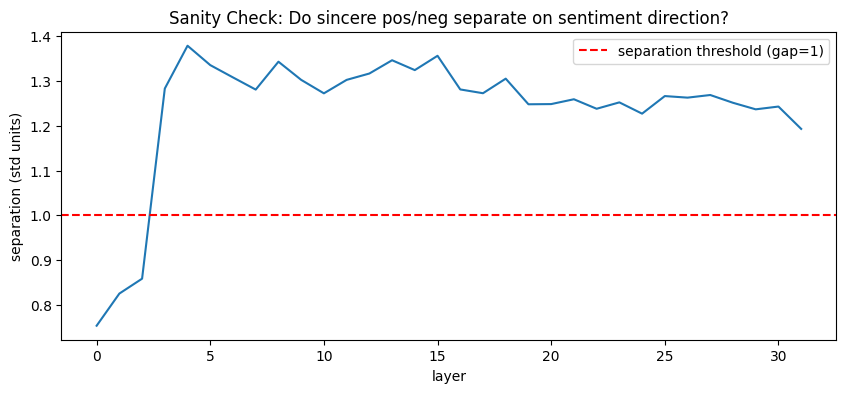

Separation by layer:
  layer 5: 1.34
  layer 10: 1.27
  layer 15: 1.36
  layer 20: 1.25
  layer 25: 1.27

✓ PASS: Best separation 1.36 at layer 15


In [17]:

# Plot it
plt.figure(figsize=(10, 4))
plt.plot(separations)
plt.axhline(1, color='r', linestyle='--', label='separation threshold (gap=1)')
plt.xlabel("layer")
plt.ylabel("separation (std units)")
plt.title("Sanity Check: Do sincere pos/neg separate on sentiment direction?")
plt.legend()
plt.savefig("sanity_check.png")
plt.show()

# Print key layers
print("Separation by layer:")
for l in [5, 10, 15, 20, 25]:
    print(f"  layer {l}: {separations[l]:.2f}")

# Kill switch
if max(separations[5:25]) < 1.0:
    print("\n KILL SWITCH: Sentiment direction doesn't separate sincere texts. Pipeline broken.")
    print("Debug: check tokenization, padding, layer choice, or data quality.")
else:
    print(f"\n✓ PASS: Best separation {max(separations[5:25]):.2f} at layer {np.argmax(separations[5:25]) + 5}")


In [18]:
import pickle
from pathlib import Path

OUT_DIR = Path("artifacts_8B")
OUT_DIR.mkdir(exist_ok=True)

# Directions — small, always worth saving
with open(OUT_DIR / "sentiment_dir.pkl", "wb") as f:
    pickle.dump(sentiment_dir, f)

# Activations — optional but cheap insurance against recompute
with open(OUT_DIR / "pos_acts.pkl", "wb") as f:
    pickle.dump(pos_acts, f)
with open(OUT_DIR / "neg_acts.pkl", "wb") as f:
    pickle.dump(neg_acts, f)

In [19]:
import gc
del pos_acts, neg_acts  # explicitly delete big vars you don't need anymore
gc.collect()
torch.cuda.empty_cache()
del model


In [2]:
sentiment_dir[0].shape

torch.Size([2304])

========================

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loaded pretrained model meta-llama/Meta-Llama-3-8B into HookedTransformer
Class sizes being projected:
  sarcastic_surfpos: 76
  paired_sincere_pos: 76
  sarcastic_surfneg: 7
  paired_sincere_neg: 7
  baseline_sincere_pos: 469
  baseline_sincere_neg: 24
Extracting activations...
  sarcastic_surfpos... 
  paired_sincere_pos... 
  sarcastic_surfneg... 
  paired_sincere_neg... 
  baseline_sincere_pos... 
  baseline_sincere_neg... 
extracting sarcastic_surfpos ...
extracting paired_sincere_pos ...
extracting sarcastic_surfneg ...
extracting paired_sincere_neg ...
extracting baseline_sincere_pos ...
extracting baseline_sincere_neg ...

Resolution score (0 = literal/surface, 1 = intended/flipped):
  layer  0: +0.06
  layer  3: +0.27
  layer  6: +0.24
  layer  9: +0.32
  layer 12: +0.31
  layer 15: +0.35
  layer 18: +0.33
  layer 21: +0.30
  layer 24: +0.33
  layer 27: +0.28
  layer 30: +0.35


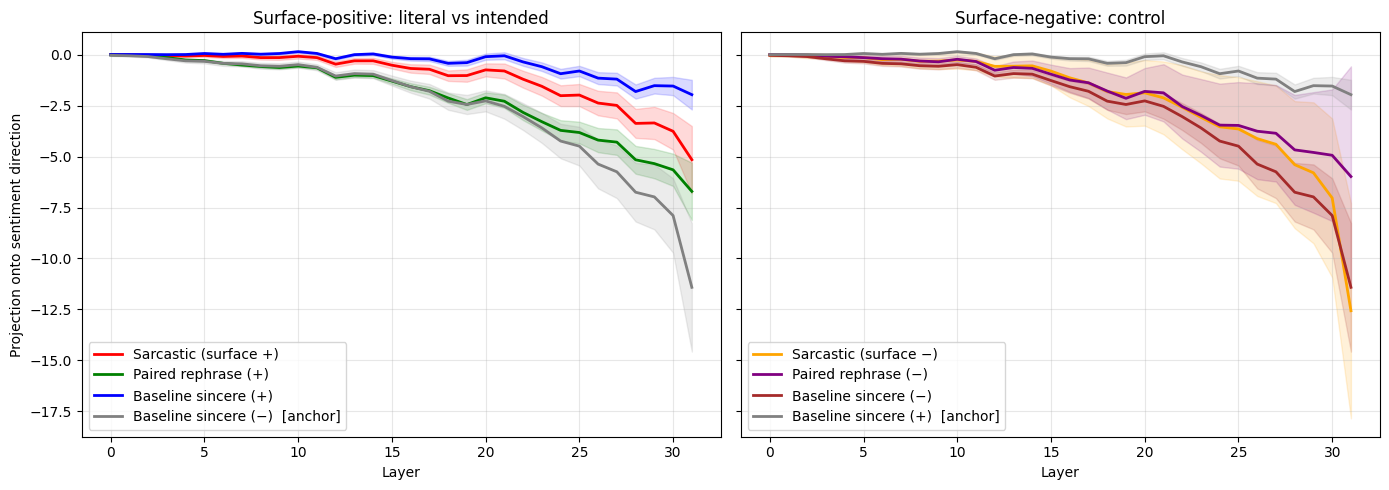

In [20]:
import torch
import pickle
import numpy as np
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer
from common_config import *

# --------------------------SETUP-------------------------------------------
device = "cuda"

# MATCH: use the same model 
model = HookedTransformer.from_pretrained(MODEL_NAME, device=device)
model.eval()
# MATCH: need to match the last step
N_DIRECTION_TRAIN = 300  #

model.tokenizer.padding_side = "right"

N_LAYERS = model.cfg.n_layers           
PAD_ID = model.tokenizer.pad_token_id
#---------------------------------------------------------------------------


#------------------------------INPUT-----------------------------------------
# GRAB classes
#classes = pickle.load(open("classes_separation0.5.pkl", "rb"))
classes = pickle.load(open(CLASSES, "rb"))

# GRAB sentiment dir
sentiment_dir = pickle.load(open("artifacts_8B/sentiment_dir.pkl", "rb"))
# sentiment_dir = pickle.load(open("sentiment_dir_strong.pkl", "rb"))

# make shift before sentiment is ready
#all_acts = {}
#for name, texts in proj_sets.items():
#    print(f"extracting {name} ...", flush=True)
#    all_acts[name] = get_resid_acts(texts)
#pickle.dump(all_acts, open("phase1_acts.pkl", "wb"))
#---------------------------------------------------------------------------


# GRAB residual activation from the model
def get_resid_acts(texts, batch_size=16):
    """dict: layer -> float32 tensor [n_texts, d_model], last real token, resid_post."""
    acts = {l: [] for l in range(N_LAYERS)}
    for i in range(0, len(texts), batch_size):
        batch = [str(t) for t in texts[i:i+batch_size]]
        tokens = model.to_tokens(batch)                       # right-padded, BOS prepended
        mask = (tokens != PAD_ID)
        last_idx = mask.sum(dim=1) - 1                        # index of last real token
        with torch.no_grad():
            _, cache = model.run_with_cache(
                tokens, names_filter=lambda n: n.endswith("hook_resid_post")
            )
        rows = torch.arange(tokens.shape[0])
        for l in range(N_LAYERS):
            resid = cache[f"blocks.{l}.hook_resid_post"]      # [batch, seq, d_model]
            acts[l].append(resid[rows, last_idx].float().cpu())
        del cache
    return {l: torch.cat(v) for l, v in acts.items()}

# GRAB CLASSES from DATAPREP
proj_sets = {
    "sarcastic_surfpos":    classes["sarcastic_surfpos"],
    "paired_sincere_pos":   classes["paired_sincere_pos"],
    "sarcastic_surfneg":    classes["sarcastic_surfneg"],
    "paired_sincere_neg":   classes["paired_sincere_neg"],
    "baseline_sincere_pos": classes["baseline_sincere_pos"][N_DIRECTION_TRAIN:],
    "baseline_sincere_neg": classes["baseline_sincere_neg"][N_DIRECTION_TRAIN:],
}



# sanity checking printout 
print("Class sizes being projected:")
for k, v in proj_sets.items():
    print(f"  {k}: {len(v)}")


# SANITY CHECK of classes(can be commented out)
print("Extracting activations...")
acts = {}
for class_name, texts in classes.items():
    print(f"  {class_name}... ", end="", flush=True)
    acts[class_name] = get_resid_acts(texts)
    print("")

# EXTRACT PROJECTION
all_projs = {}   # name -> array [N_LAYERS, n_texts] of per-text projections
for name, texts in proj_sets.items():
    print(f"extracting {name} ...", flush=True)
    a = get_resid_acts(texts)
    all_projs[name] = np.stack(
        [(a[l] @ sentiment_dir[l]).numpy() for l in range(N_LAYERS)]
    )
    del a


pickle.dump(all_projs, open("artifacts_8B/phase1_projections_strong.pkl", "wb"))    

#-----Little plot class-------------
def plot_class(ax, name, color, label):
    m = all_projs[name].mean(axis=1)
    sem = all_projs[name].std(axis=1) / np.sqrt(all_projs[name].shape[1])
    ax.plot(m, color=color, linewidth=2, label=label)
    ax.fill_between(range(N_LAYERS), m - 2*sem, m + 2*sem, color=color, alpha=0.15)

#-----plotting how sentiment evolve over time
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

ax = axes[0]
plot_class(ax, "sarcastic_surfpos",    "red",   "Sarcastic (surface +)")
plot_class(ax, "paired_sincere_pos",   "green", "Paired rephrase (+)")
plot_class(ax, "baseline_sincere_pos", "blue",  "Baseline sincere (+)")
plot_class(ax, "baseline_sincere_neg", "gray",  "Baseline sincere (−)  [anchor]")
ax.set_xlabel("Layer"); ax.set_ylabel("Projection onto sentiment direction")
ax.set_title("Surface-positive: literal vs intended"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
plot_class(ax, "sarcastic_surfneg",    "orange", "Sarcastic (surface −)")
plot_class(ax, "paired_sincere_neg",   "purple", "Paired rephrase (−)")
plot_class(ax, "baseline_sincere_neg", "brown",  "Baseline sincere (−)")
plot_class(ax, "baseline_sincere_pos", "gray",   "Baseline sincere (+)  [anchor]")
ax.set_xlabel("Layer"); ax.set_title("Surface-negative: control"); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("phase1_headline_strong.png", dpi=150)

pos_anchor = all_projs["baseline_sincere_pos"].mean(axis=1)
neg_anchor = all_projs["baseline_sincere_neg"].mean(axis=1)
sarc       = all_projs["sarcastic_surfpos"].mean(axis=1)
resolution = (pos_anchor - sarc) / (pos_anchor - neg_anchor)

print("\nResolution score (0 = literal/surface, 1 = intended/flipped):")
for l in range(0, N_LAYERS, 3):
    print(f"  layer {l:2d}: {resolution[l]:+.2f}")
pickle.dump(resolution, open("artifacts_8B/phase1_resolution_strong.pkl", "wb"))




sarcastic VADER: 0.71 ± 0.13
baseline  VADER: 0.73 ± 0.13
sarcastic neg VADER: -0.68 ± 0.13
baseline  neg VADER: -0.68 ± 0.13
92
92
324
sarcastic: ANY PENSIONER AND 4 YEAR OLD WHO DARE TAKE ME ON AT DINOSAUR THEMED CRAZY GOLF WILL BE CRUSHED, CRUSHED I TELL YOU. https://t.co/yZlafy0lsd
rephrase:  Had a great time playing crazy golf with the family, and I won!

sarcastic: @heathoween @tylerrjoseph Yes, because we need literally every single fucking celebrity to speak up on a topic that's been forced down everyone's throats for the past four months. I use the internet to get away from these fucking real life problems; not everyone needs to weigh in.
rephrase:  "Not every celebrity needs to weigh in on every political issue there is"

sarcastic: Not got one lynx Africa for Christmas Day this year, shocked and outraged. #RuinedChristmas
rephrase:  Lynx Africa is terrible and I’m glad I didn’t get one for Christmas this year 

layer 8: mean Δ=+0.4, p=5.1e-09
layer 12: mean Δ=+0.6, p=2.1e-09

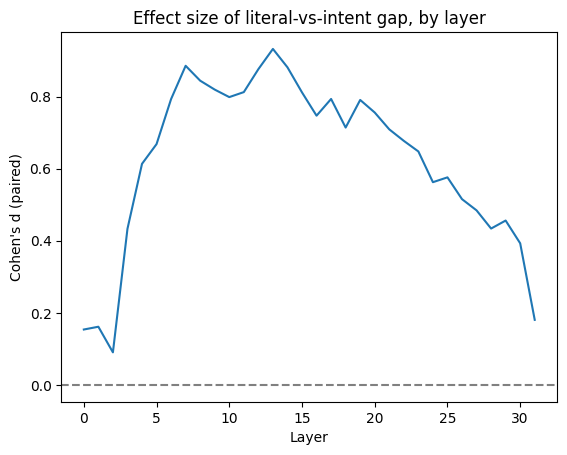

In [21]:
import pickle
import numpy as np

#constant
artifacts_folder="artifacts_8B"


classes = pickle.load(open("classes_separation0.5.pkl", "rb"))
#
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()
def surface(t):
    return analyzer.polarity_scores(str(t))["compound"]

sarc_v = np.array([surface(t) for t in classes["sarcastic_surfpos"]])
base_v = np.array([surface(t) for t in classes["baseline_sincere_pos"]])

print(f"sarcastic VADER: {sarc_v.mean():.2f} ± {sarc_v.std():.2f}")
print(f"baseline  VADER: {base_v.mean():.2f} ± {base_v.std():.2f}")

sarc_neg_v = np.array([surface(t) for t in classes["sarcastic_surfneg"]])
base_neg_v = np.array([surface(t) for t in classes["baseline_sincere_neg"]])
print(f"sarcastic neg VADER: {sarc_neg_v.mean():.2f} ± {sarc_neg_v.std():.2f}")
print(f"baseline  neg VADER: {base_neg_v.mean():.2f} ± {base_neg_v.std():.2f}")

print(len(classes["sarcastic_surfneg"]))
print(len(classes["paired_sincere_neg"]))
print(len(classes["baseline_sincere_neg"]))

for i in range(3):
    print(f"sarcastic: {classes['sarcastic_surfneg'][i]}")
    print(f"rephrase:  {classes['paired_sincere_neg'][i]}")
    print()



import pickle
from scipy.stats import wilcoxon

all_projs = pickle.load(open("artifacts_8B/phase1_projections_strong.pkl", "rb"))

sarc = all_projs["sarcastic_surfpos"]      # [layers, n]
intent = all_projs["paired_sincere_pos"]   # same order = same pairs, since both built from pairs_df in order
delta = sarc - intent

for l in [8, 12, 16, 20]:
    w = wilcoxon(delta[l])
    print(f"layer {l}: mean Δ={delta[l].mean():+.1f}, p={w.pvalue:.1e}")

#TEST 3
import numpy as np
N_LAYERS = delta.shape[0]
effect_sizes = []
for l in range(N_LAYERS):
    d = delta[l]
    cohens_d = d.mean() / d.std()   # standardized effect size for paired data
    effect_sizes.append(cohens_d)

import matplotlib.pyplot as plt
plt.plot(effect_sizes)
plt.xlabel("Layer"); plt.ylabel("Cohen's d (paired)")
plt.title("Effect size of literal-vs-intent gap, by layer")
plt.axhline(0, color='gray', linestyle='--')
plt.savefig(f"{artifacts_folder}/effect_size_by_layer.png")


# effect size on the raw unpaired comparison 
base = all_projs["baseline_sincere_pos"]
for l in [8, 12, 16, 20]:
    unpaired_d = (sarc[l].mean() - base[l].mean()) / np.sqrt((sarc[l].var() + base[l].var()) / 2)
    print(f"layer {l}: unpaired Cohen's d = {unpaired_d:.2f}")

